# Ex8 — Labelled cells: dense fluorescence under different illuminations

Cell-biology images are dense: fluorophores fill membranes and cytoplasm rather than sitting at a
few points. gradix describes cells as solids with a label, rasterises them onto the grid its
dense imaging element asks for, and images them plane by plane with pupil PSFs
(`gx.imaging.Strata`). This example follows one population of rod-shaped bacteria through:

1. their **labels as densities** (a membrane label on the surface, a cytoplasm label in the
   volume) on the grid Strata chose;
2. a **two-colour widefield** image;
3. **light-sheet** excitation, which lights only the focal plane;
4. **structured illumination** (SIM) raw frames;
5. imaging **deep in scattering tissue** (a turbid slab);
6. letting **`gx.plan`** choose the method: a fast periodic convolution at `draft`, the exact
   one at `accurate`.

**Level** L3 (Chains and Pipelines) and L4 (`gx.plan`) · **Prerequisites** T1 · **Runtime** a
few seconds on a GPU. `SMOKE` (set by the test suite) shrinks the scene, so the notebook also
runs in seconds on a CPU.

In [1]:
import math
import os
import time

import matplotlib.pyplot as plt
import numpy as np
import torch

import gradix as gx

SMOKE = os.environ.get("GRADIX_SMOKE") == "1"
DEVICE = "cuda" if torch.cuda.is_available() and not SMOKE else "cpu"
plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.titlesize": 9})
g = torch.Generator().manual_seed(2)


def to_numpy(t: torch.Tensor) -> np.ndarray:
    """Return a CPU NumPy copy of a tensor, for plotting."""
    return t.detach().cpu().numpy()


def lying(theta: torch.Tensor) -> torch.Tensor:
    """Return quaternions (w, x, y, z) that lay a capsule's axis in the xy plane at angle θ."""
    c, a, b = math.sqrt(0.5), torch.cos(theta / 2), torch.sin(theta / 2)
    return torch.stack([a * c, -b * c, a * c, b * c], -1)  # q_z(θ) ⊗ q_y(90°)

## 1. Bacteria as labelled solids

Capsules model rod-shaped bacteria: `length` tip to tip and `radius`, lying on random headings
at depths within ±1 µm of the focal plane of an NA 1.2 water-immersion objective. The same geometry carries two labels: a membrane
dye on the surface (`surface_density`, photons per µm²) and a cytoplasmic protein in the volume
(`density`, photons per µm³), each with its own emission line.

In [2]:
N = 6 if SMOKE else 16
camera = gx.Camera(pixel_size=6.5, shape=(40, 40) if SMOKE else (96, 96))
objective = gx.Objective(NA=1.2, magnification=65)  # water immersion; 100 nm pixels
medium = gx.env.Homogeneous(1.33)
fov = gx.coords.field_of_view(camera, objective)

position = torch.cat(
    [
        (0.15 + 0.7 * torch.rand(1, N, 2, generator=g)) * fov,
        2.0 * torch.rand(1, N, 1, generator=g) - 1.0,
    ],
    -1,
)  # [1, N, 3] µm
rotation = lying(math.pi * torch.rand(1, N, generator=g))
length = 1.6 + 1.4 * torch.rand(1, N, generator=g)  # µm, tip to tip
radius = 0.33 + 0.1 * torch.rand(1, N, generator=g)  # µm
membrane_label = gx.Labeling(emission=gx.Spectrum.line(0.60), surface_density=60.0)
cytoplasm_label = gx.Labeling(emission=gx.Spectrum.line(0.52), density=40.0)
membrane = gx.Capsules(
    position=position, rotation=rotation, length=length, radius=radius, labeling=membrane_label
)
cytoplasm = gx.Capsules(
    position=position, rotation=rotation, length=length, radius=radius, labeling=cytoplasm_label
)


def render(
    cells: gx.Solid, imaging: gx.imaging.Strata | None = None, light: gx.Element | None = None
) -> tuple[torch.Tensor, gx.Pipeline]:
    """Render the expected image of one labelled population, optionally excited by light."""
    scene = gx.Chain(
        emitters={"cells": cells},
        imaging=imaging or gx.imaging.Strata(objective, camera),
        environment=medium,
        light=light,
        excite=gx.excite.Linear() if light is not None else None,
    )
    scene = gx.tree.to(scene, DEVICE)
    pipe = gx.Pipeline(scene, outputs=("expected",))
    return pipe(scene).expected.cpu(), pipe


strata = gx.imaging.Strata(objective, camera)
widefield, pipe = render(membrane, imaging=strata)
request = strata.density_request(pipe.static("imaging"))  # the grid Strata asked for
assert request is not None
print(request.grid)
print(pipe.explain().split("sampling")[1].split(" # stage")[0])

VolumeGrid(xy=Grid2D(shape=(128, 128), spacing=0.1, origin=(-1.6, -1.6)), z0=-3.26444988965227, dz=0.33046840943708106, nz=20)
   imaging: detection.spacing = 0.1  ← pitch/s, s the smallest integer with spacing <= λ_min/(2·2.4) = 0.1042 µm (auto)
           imaging: pupil.samples = 210  ← max(64, period λ_min/du ≥ offsets + PSF)
           imaging: raster.planes = 20  ← solids' z range ± reach, spacing λ_min/(2(n − √(n² − NA²)))



The Pipeline's `explain()` shows the grid Strata asked for (ADR-41): its own fine lateral
grid over the frame and a margin, and planes over the cells' depth range at the axial Nyquist
spacing, where each plane holds a band-limited mix of neighbouring depths. The same lowering on a
finer grid of planes shows the labels themselves: shells for the membrane, filled rods for the
cytoplasm.

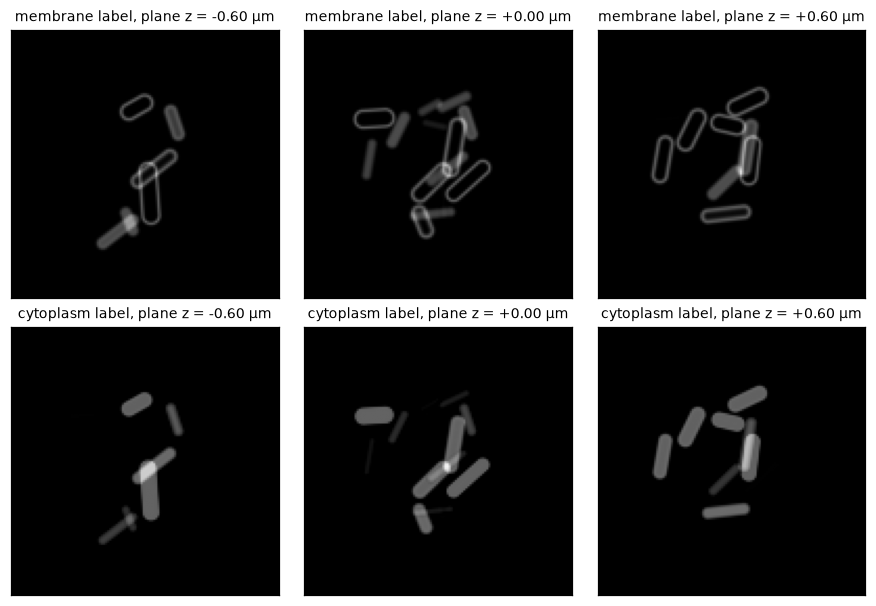

In [3]:
fine = gx.VolumeGrid(xy=request.grid.xy, z0=-1.5, dz=0.1, nz=31)  # a display grid
shells = gx.lower.label_density(membrane, fine, sigma=request.blur, reach=request.reach["cells"])[
    0, 0
]
filled = gx.lower.label_density(cytoplasm, fine, sigma=request.blur, reach=request.reach["cells"])[
    0, 0
]
planes = fine.z().tolist()
chosen = [int(np.argmin([abs(z - target) for z in planes])) for target in (-0.6, 0.0, 0.6)]
fig, axes = plt.subplots(2, 3, figsize=(8.0, 5.4), layout="constrained")
for col, k in enumerate(chosen):
    for row, (name, density) in enumerate([("membrane", shells), ("cytoplasm", filled)]):
        ax = axes[row, col]
        ax.imshow(to_numpy(density[k]), cmap="gray", vmin=0, vmax=float(density.max()))
        ax.set_title(f"{name} label, plane z = {planes[k]:+.2f} µm")
        ax.set_xticks([])
        ax.set_yticks([])
plt.show()

## 2. Two-colour widefield

Each label is rendered on its own (one channel per emission band) and composited: membrane in
magenta, cytoplasm in green. Cells far from focus blur into haze.

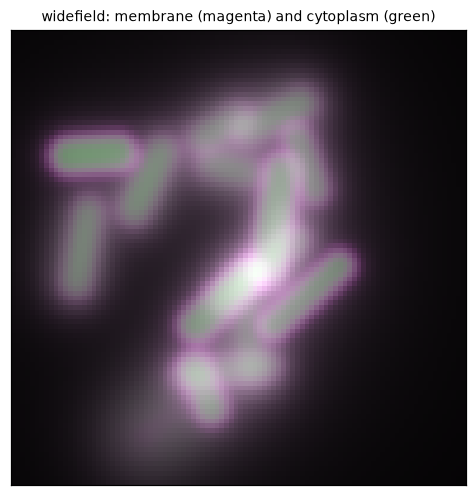

In [4]:
green, _ = render(cytoplasm)


def composite(magenta: torch.Tensor, green: torch.Tensor) -> np.ndarray:
    """Return an RGB image: one channel magenta, the other green, each scaled to its maximum."""
    m = (magenta / magenta.max()).clamp(0, 1).sqrt()  # a square-root display: dim cells show
    c = (green / green.max()).clamp(0, 1).sqrt()
    return to_numpy(torch.stack([m, c, m], -1))


fig, ax = plt.subplots(figsize=(4.4, 4.4), layout="constrained")
ax.imshow(composite(widefield[0, 0], green[0, 0]))
ax.set_title("widefield: membrane (magenta) and cytoplasm (green)")
ax.set_xticks([])
ax.set_yticks([])
plt.show()

## 3. Light-sheet excitation

Sectioning matters in thick samples, so this section fills a 5 µm deep volume with more cells.
A Gaussian light sheet (`gx.light.Sheet`) travels along x through the focal plane, its waist
(0.6 µm, 1/e² half-width) in the middle of the frame; `gx.excite.Linear` scales every voxel's
emission by the local irradiance on the density grid. Under widefield illumination the cells
above and below focus add a haze; under the sheet they stay dark. The right panel reads each
cell's excitation straight from the sheet (`sheet().at(points, n)`); cells off the frame's
centre sit a little above the waist profile, because the sheet widens away from its waist.

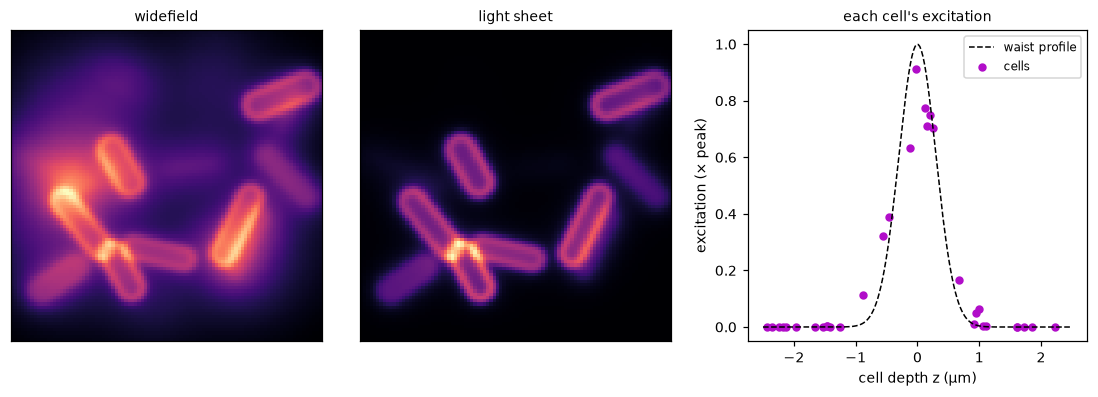

In [5]:
M = 2 * N
thick_position = torch.cat(
    [
        (0.1 + 0.8 * torch.rand(1, M, 2, generator=g)) * fov,
        5.0 * torch.rand(1, M, 1, generator=g) - 2.5,
    ],
    -1,
)
thick = gx.Capsules(
    position=thick_position,
    rotation=lying(math.pi * torch.rand(1, M, generator=g)),
    length=1.6 + 1.4 * torch.rand(1, M, generator=g),
    radius=0.33 + 0.1 * torch.rand(1, M, generator=g),
    labeling=membrane_label,
)
thick_widefield, _ = render(thick)
sheet_light = gx.light.Sheet(waist=0.6, center=0.0, focus=float(fov[0]) / 2, wavelength=0.488)
sheet, _ = render(thick, light=sheet_light)
fig, axes = plt.subplots(1, 3, figsize=(10.0, 3.5), layout="constrained")
for ax, (name, frame) in zip(
    axes, [("widefield", thick_widefield), ("light sheet", sheet)], strict=False
):
    ax.imshow(to_numpy(frame[0, 0] / frame.max()), cmap="magma")
    ax.set_title(name)
    ax.set_xticks([])
    ax.set_yticks([])
field = sheet_light().at(thick_position[:, None], 1.33)  # [1, 1, 1, L, 1, M]
excitation = field.abs().square().reshape(-1)
depth = thick_position[0, :, 2]
z = torch.linspace(-2.5, 2.5, 200)
axes[2].plot(
    to_numpy(z), to_numpy(torch.exp(-2 * (z / 0.6) ** 2)), "k--", lw=1, label="waist profile"
)
axes[2].scatter(to_numpy(depth), to_numpy(excitation), s=20, color="#b10dc9", label="cells")
axes[2].set_xlabel("cell depth z (µm)")
axes[2].set_ylabel("excitation (× peak)")
axes[2].legend(fontsize=8)
axes[2].set_title("each cell's excitation")
plt.show()

## 4. Structured illumination

`gx.light.SIMBeams` interferes two beams into a sinusoidal pattern; a tensor of three phases gives
three images in one call (one per image of the batch). The raw frames carry the fringes whose
beat with the sample's structure SIM reconstruction decodes; their mean is the uniformly lit
image.

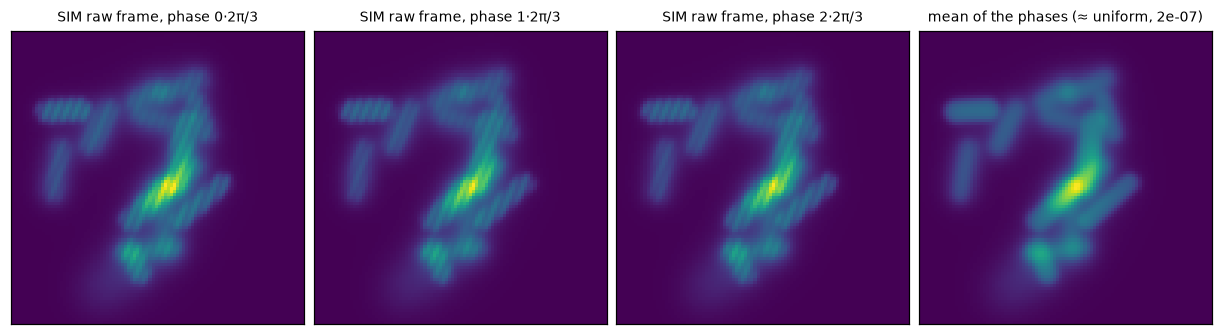

In [6]:
phases = torch.tensor([0.0, 2 * math.pi / 3, 4 * math.pi / 3])
sim_light = gx.light.SIMBeams(period=0.30, angle=0.4, phase=phases, wavelength=0.488)
raw, _ = render(cytoplasm, light=sim_light)
uniform, _ = render(cytoplasm, light=gx.light.Uniform(wavelength=0.488))
fig, axes = plt.subplots(1, 4, figsize=(11.0, 3.0), layout="constrained")
for i in range(3):
    axes[i].imshow(to_numpy(raw[i, 0]), cmap="viridis")
    axes[i].set_title(f"SIM raw frame, phase {i}·2π/3")
axes[3].imshow(to_numpy(raw[:, 0].mean(0)), cmap="viridis")
agree = float((raw[:, 0].mean(0) - uniform[0, 0]).abs().max() / uniform.max())
axes[3].set_title(f"mean of the phases (≈ uniform, {agree:.0e})")
for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])
plt.show()

## 5. Deep in tissue

A phenomenological turbid slab (`gx.env.TurbidSlab`) attenuates light with depth below its
surface, blurs what is left and spreads the scattered part into a diffuse halo. Cells deeper
below the surface (here: lower z) come out dimmer and softer.

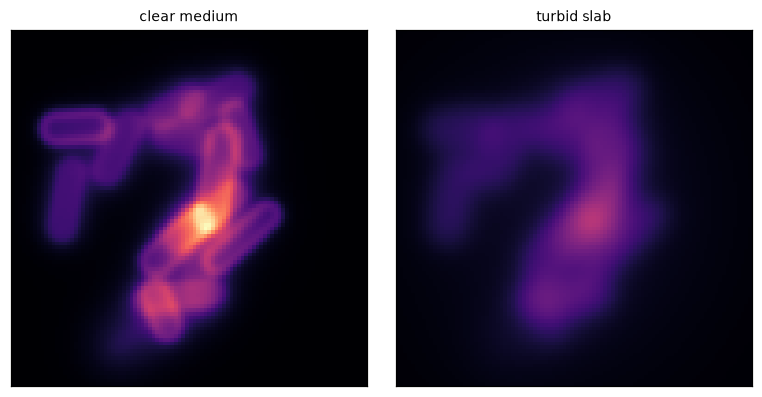

In [7]:
slab = gx.env.TurbidSlab(attenuation=0.4, blur=0.2, diffuse=3.0, surface=1.5)
deep, _ = render(membrane, imaging=gx.imaging.Strata(objective, camera, turbid=slab))
fig, axes = plt.subplots(1, 2, figsize=(7.0, 3.5), layout="constrained")
for ax, (name, frame) in zip(
    axes, [("clear medium", widefield), ("turbid slab", deep)], strict=False
):
    ax.imshow(to_numpy(frame[0, 0]), cmap="magma", vmin=0, vmax=float(widefield.max()))
    ax.set_title(name)
    ax.set_xticks([])
    ax.set_yticks([])
plt.show()

## 6. Let the planner choose

At L4, `gx.plan` routes labelled solids to Strata and picks its convolution from the fidelity:
the periodic one (fast, light near an edge wraps to the opposite one) at `draft` and
`standard`, the exact linear one at `accurate` and `reference`. `draft` also rasterises with a
wider prefilter (σ_r = 0.5 voxels against 0.3), so the two renders differ most along the cells'
sharp edges. At this small frame they cost about the same; the periodic convolution pulls ahead
as frames and depth ranges grow (2.5× at 256² with 32 planes).

draft     → emit.strata_otf: boundary='periodic', raster_sigma=0.5, oversample=1, 25 ms
accurate  → emit.strata_otf: boundary='linear', raster_sigma=0.3, oversample='auto', 25 ms


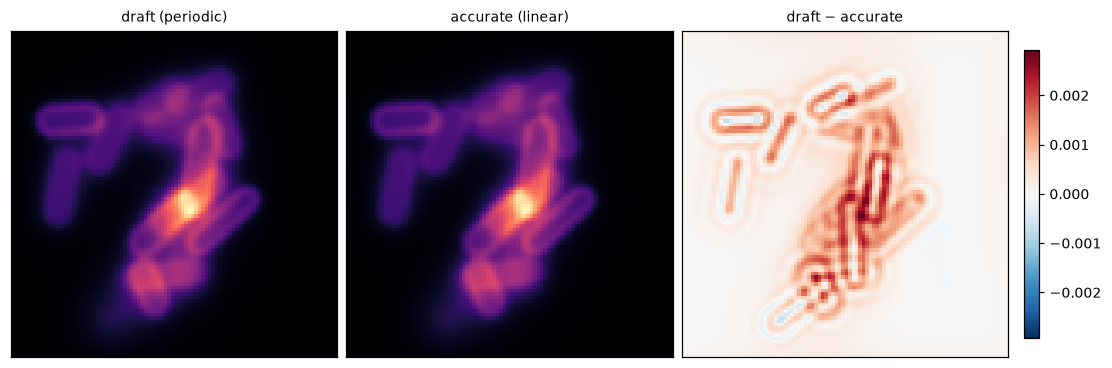

In [8]:
sample = gx.Sample({"cells": membrane}, environment=medium)
scope = gx.presets.Widefield(objective=objective, camera=camera)
renders = {}
for preset in ("draft", "accurate"):
    planned = gx.plan(
        gx.tree.to(sample, DEVICE), gx.tree.to(scope, DEVICE), preset, outputs=("expected",)
    )
    planned(gx.tree.to(sample, DEVICE), gx.tree.to(scope, DEVICE))  # warm-up
    start = time.perf_counter()
    renders[preset] = planned(gx.tree.to(sample, DEVICE), gx.tree.to(scope, DEVICE)).expected.cpu()
    elapsed = time.perf_counter() - start
    imaging = planned.chain(gx.tree.to(sample, DEVICE), gx.tree.to(scope, DEVICE)).imaging
    assert isinstance(imaging, gx.imaging.Strata)
    print(
        f"{preset:9s} → {planned.routes['cells'].element}: boundary={imaging.boundary!r}, "
        f"raster_sigma={imaging.raster_sigma}, oversample={imaging.oversample!r}, "
        f"{1000 * elapsed:.0f} ms"
    )
difference = renders["draft"] - renders["accurate"]
fig, axes = plt.subplots(1, 3, figsize=(10.0, 3.4), layout="constrained")
for ax, (name, frame) in zip(
    axes,
    [("draft (periodic)", renders["draft"]), ("accurate (linear)", renders["accurate"])],
    strict=False,
):
    ax.imshow(to_numpy(frame[0, 0]), cmap="magma")
    ax.set_title(name)
limit = float(difference.abs().max())
im = axes[2].imshow(to_numpy(difference[0, 0]), cmap="RdBu_r", vmin=-limit, vmax=limit)
axes[2].set_title("draft − accurate")
fig.colorbar(im, ax=axes[2], shrink=0.8)
for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])
plt.show()

## Recap

- Cells are solids with labels; one geometry drives every label and, from M3, the refractive
  index too, so fluorescence and label-free renders of the same cells stay consistent.
- Strata chooses the density grid (ADR-41) and the raster lowering fills it, with exact photon
  budgets and gradients to every shape and label field.
- Excitation works on the density grid: uniform, light sheet and SIM are a change of `light=`.
- Fidelity presets pick the convolution; `explain()` shows the grid and why.